**© Copyright AIDENTIFY. All rights reserved.**

본 자료는 **멀티캠퍼스 LLM 파인튜닝 과정** 수강생을 위해 제작되었으며, 강의 목적으로만 사용 가능합니다.  
무단 복제, 배포, 상업적 이용을 금지합니다.

---

# 🎯 LLM 발전 과정과 활용 방법론

## Part 1 | Session 2: LLM 발전, 프롬프트 엔지니어링 / RAG / Agent / 파인튜닝 개요

---

### 📋 학습 목표

- 🔹 LLM의 발전 과정(GPT-1 → GPT-4, LLaMA, Qwen 등)을 이해합니다
- 🔹 주요 LLM 모델들의 특징과 차이점을 비교합니다
- 🔹 sLLM(Small LLM)의 부상 배경과 실용성을 파악합니다
- 🔹 LLM 활용 4가지 방법(프롬프트 엔지니어링, RAG, Agent, 파인튜닝)을 비교합니다
- 🔹 각 방법의 적합한 사용 사례를 판단할 수 있습니다

### 📦 필요 라이브러리

```
matplotlib
```

### ⏱️ 예상 소요 시간: 약 60분

---

In [1]:
# 필요 라이브러리 설치 (이미 설치되어 있다면 스킵)
# !pip install matplotlib

import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Ubuntu/Linux)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료!")
print(f"  - matplotlib 버전: {matplotlib.__version__}")

✅ 라이브러리 임포트 완료!
  - matplotlib 버전: 3.10.8


---

## 🎯 LLM 발전 과정

### 시대별 주요 모델 타임라인

```
2017  Transformer ("Attention Is All You Need") - Google
  │
2018  GPT-1 (117M) - OpenAI          BERT (340M) - Google
  │
2019  GPT-2 (1.5B) - OpenAI          T5 (11B) - Google
  │
2020  GPT-3 (175B) - OpenAI
  │
2021  Codex - OpenAI                  PaLM - Google
  │
2022  ChatGPT - OpenAI               InstructGPT - OpenAI
  │    LLaMA (7~65B) - Meta
  │
2023  GPT-4 - OpenAI                 LLaMA 2 (7~70B) - Meta
  │    Claude 2 - Anthropic          Mistral 7B - Mistral AI
  │    Qwen (7~72B) - Alibaba
  │
2024  GPT-4o - OpenAI                LLaMA 3 (8~405B) - Meta
  │    Claude 3.5 Sonnet - Anthropic Qwen2.5 (0.5~72B) - Alibaba
  │    Gemini 1.5 - Google           DeepSeek V3/R1 - DeepSeek
  │    Phi-3 (mini~medium) - Microsoft
  │
2025  GPT-4.5/o3 - OpenAI            LLaMA 4 - Meta
       Claude 4 - Anthropic           Qwen3 - Alibaba
       Gemini 2.5 - Google
```

### 핵심 트렌드

- 🔸 **규모의 확대**: 117M → 175B → 1T+ 파라미터
- 🔸 **오픈소스 확산**: LLaMA, Qwen, Mistral 등 오픈 가중치 공개
- 🔸 **효율성 추구**: sLLM으로 작지만 강력한 모델 개발
- 🔸 **멀티모달**: 텍스트 + 이미지 + 오디오 통합
- 🔸 **추론 능력**: CoT, 강화학습 기반 추론 모델 (o1, R1)

---

📈 LLM 발전 타임라인 시각화


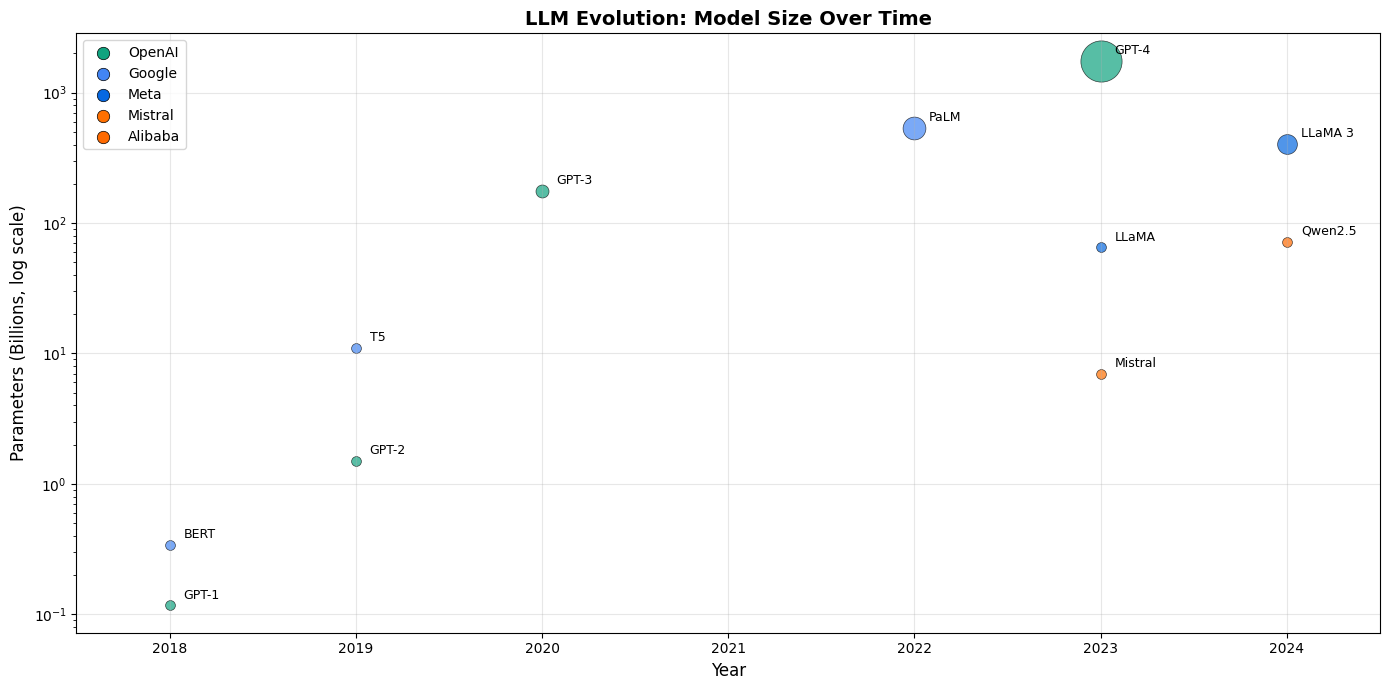


✅ 모델 크기가 지수적으로 증가하는 트렌드를 확인할 수 있습니다.
💡 하지만 최근에는 '작지만 강력한' sLLM도 주목받고 있습니다!


In [2]:
# LLM 발전 타임라인 시각화
print("=" * 60)
print("📈 LLM 발전 타임라인 시각화")
print("=" * 60)

# 주요 모델 데이터
models = [
    {"name": "GPT-1", "year": 2018, "params": 0.117, "org": "OpenAI"},
    {"name": "BERT", "year": 2018, "params": 0.340, "org": "Google"},
    {"name": "GPT-2", "year": 2019, "params": 1.5, "org": "OpenAI"},
    {"name": "T5", "year": 2019, "params": 11, "org": "Google"},
    {"name": "GPT-3", "year": 2020, "params": 175, "org": "OpenAI"},
    {"name": "PaLM", "year": 2022, "params": 540, "org": "Google"},
    {"name": "LLaMA", "year": 2023, "params": 65, "org": "Meta"},
    {"name": "GPT-4", "year": 2023, "params": 1760, "org": "OpenAI"},
    {"name": "Mistral", "year": 2023, "params": 7, "org": "Mistral"},
    {"name": "LLaMA 3", "year": 2024, "params": 405, "org": "Meta"},
    {"name": "Qwen2.5", "year": 2024, "params": 72, "org": "Alibaba"},
]

fig, ax = plt.subplots(figsize=(14, 7))

# 조직별 색상
colors = {
    "OpenAI": "#10a37f",
    "Google": "#4285f4",
    "Meta": "#0668E1",
    "Mistral": "#FF7000",
    "Alibaba": "#FF6A00",
}

for m in models:
    color = colors.get(m["org"], "gray")
    ax.scatter(m["year"], m["params"], s=max(50, m["params"] * 0.5), 
              c=color, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.annotate(m["name"], (m["year"], m["params"]), 
               textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_yscale('log')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Parameters (Billions, log scale)', fontsize=12)
ax.set_title('LLM Evolution: Model Size Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(2017.5, 2024.5)

# 범례
for org, color in colors.items():
    ax.scatter([], [], c=color, s=80, label=org, edgecolors='black', linewidth=0.5)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ 모델 크기가 지수적으로 증가하는 트렌드를 확인할 수 있습니다.")
print("💡 하지만 최근에는 '작지만 강력한' sLLM도 주목받고 있습니다!")

---

## 1️⃣ 주요 LLM 모델 비교

### 클로즈드소스 모델 (API 제공)

| 모델 | 개발사 | 특징 | 비용 |
|------|--------|------|------|
| GPT-4o | OpenAI | 멀티모달, 빠른 속도 | 입력 $2.5/1M, 출력 $10/1M |
| GPT-4.5 | OpenAI | 향상된 EQ/창의성 | 입력 $75/1M, 출력 $150/1M |
| Claude 3.5 Sonnet | Anthropic | 코딩 강점, 안전성 | 입력 $3/1M, 출력 $15/1M |
| Gemini 1.5 Pro | Google | 100만 토큰 컨텍스트 | 입력 $1.25/1M, 출력 $5/1M |

### 오픈소스/오픈가중치 모델

| 모델 | 개발사 | 크기 | 특징 |
|------|--------|------|------|
| LLaMA 3.1 | Meta | 8B/70B/405B | 가장 인기있는 오픈소스 |
| Qwen2.5 | Alibaba | 0.5B~72B | 다국어 우수, 한국어 양호 |
| Mistral/Mixtral | Mistral AI | 7B/8x7B | MoE 아키텍처, 효율적 |
| Phi-3/3.5 | Microsoft | 3.8B/7B | 작지만 강력한 성능 |
| DeepSeek R1 | DeepSeek | 7B~671B | 추론 특화, 강화학습 |
| Gemma 2 | Google | 2B/9B/27B | 경량 연구용 |
| EXAONE 3.5 | LG AI Research | 2.4B/7.8B/32B | 한국어 특화 |

---

In [3]:
# 주요 오픈소스 모델 비교 표 출력
print("=" * 80)
print("📊 주요 오픈소스 LLM 모델 비교 (2024-2025 기준)")
print("=" * 80)

models_comparison = [
    {
        "name": "LLaMA 3.1 8B",
        "org": "Meta",
        "params": "8B",
        "context": "128K",
        "license": "Meta License",
        "korean": "보통",
        "strength": "커뮤니티 생태계",
    },
    {
        "name": "Qwen2.5 7B",
        "org": "Alibaba",
        "params": "7B",
        "context": "128K",
        "license": "Apache 2.0",
        "korean": "양호",
        "strength": "다국어, 코딩",
    },
    {
        "name": "Mistral 7B",
        "org": "Mistral AI",
        "params": "7B",
        "context": "32K",
        "license": "Apache 2.0",
        "korean": "보통",
        "strength": "효율성, 속도",
    },
    {
        "name": "Phi-3.5 Mini",
        "org": "Microsoft",
        "params": "3.8B",
        "context": "128K",
        "license": "MIT",
        "korean": "보통",
        "strength": "크기 대비 성능",
    },
    {
        "name": "Gemma 2 9B",
        "org": "Google",
        "params": "9B",
        "context": "8K",
        "license": "Gemma License",
        "korean": "보통",
        "strength": "연구 친화적",
    },
    {
        "name": "EXAONE 3.5 7.8B",
        "org": "LG AI",
        "params": "7.8B",
        "context": "32K",
        "license": "EXAONE License",
        "korean": "우수",
        "strength": "한국어 특화",
    },
]

# 표 형태로 출력
header = f"{'모델':<20} {'개발사':<12} {'파라미터':<10} {'컨텍스트':<10} {'한국어':<8} {'강점':<15}"
print(f"\n{header}")
print("-" * 80)

for m in models_comparison:
    row = f"{m['name']:<20} {m['org']:<12} {m['params']:<10} {m['context']:<10} {m['korean']:<8} {m['strength']:<15}"
    print(row)

print("\n" + "=" * 80)
print("💡 우리 실습에서는 Qwen2.5-1.5B-Instruct를 주로 사용합니다!")
print("   → RTX 4060 (8GB)에서 LoRA/QLoRA 가능한 크기")

📊 주요 오픈소스 LLM 모델 비교 (2024-2025 기준)

모델                   개발사          파라미터       컨텍스트       한국어      강점             
--------------------------------------------------------------------------------
LLaMA 3.1 8B         Meta         8B         128K       보통       커뮤니티 생태계       
Qwen2.5 7B           Alibaba      7B         128K       양호       다국어, 코딩        
Mistral 7B           Mistral AI   7B         32K        보통       효율성, 속도        
Phi-3.5 Mini         Microsoft    3.8B       128K       보통       크기 대비 성능       
Gemma 2 9B           Google       9B         8K         보통       연구 친화적         
EXAONE 3.5 7.8B      LG AI        7.8B       32K        우수       한국어 특화         

💡 우리 실습에서는 Qwen2.5-1.5B-Instruct를 주로 사용합니다!
   → RTX 4060 (8GB)에서 LoRA/QLoRA 가능한 크기


---

## 2️⃣ sLLM(Small LLM)의 부상과 실용성

### sLLM이란?

일반적으로 **7B 이하**의 파라미터를 가진 경량 언어 모델을 sLLM이라 합니다.

### sLLM이 주목받는 이유

| 장점 | 설명 |
|------|------|
| 💰 비용 절감 | 운영/추론 비용이 대형 모델의 1/10~1/100 |
| 🔒 데이터 보안 | 로컬/프라이빗 환경에서 실행 가능 |
| ⚡ 빠른 추론 | 낮은 지연시간(latency) |
| 🎯 특화 가능 | 파인튜닝으로 특정 도메인에 최적화 |
| 🖥️ 접근성 | 일반 GPU(8~24GB)에서 실행 가능 |

### 파인튜닝된 sLLM의 강점

```
범용 대형 모델 (GPT-4, 1.76T)
  → 모든 분야에서 80~90점

파인튜닝된 sLLM (Qwen2.5-1.5B + 도메인 데이터)
  → 특정 분야에서 85~95점 (대형 모델과 비슷하거나 더 나은 성능!)
  → 비용은 1/100, 속도는 10배 빠름
```

### 이것이 우리가 파인튜닝을 배우는 이유입니다!

---

📊 sLLM vs 대형 모델: 비용-성능 트레이드오프


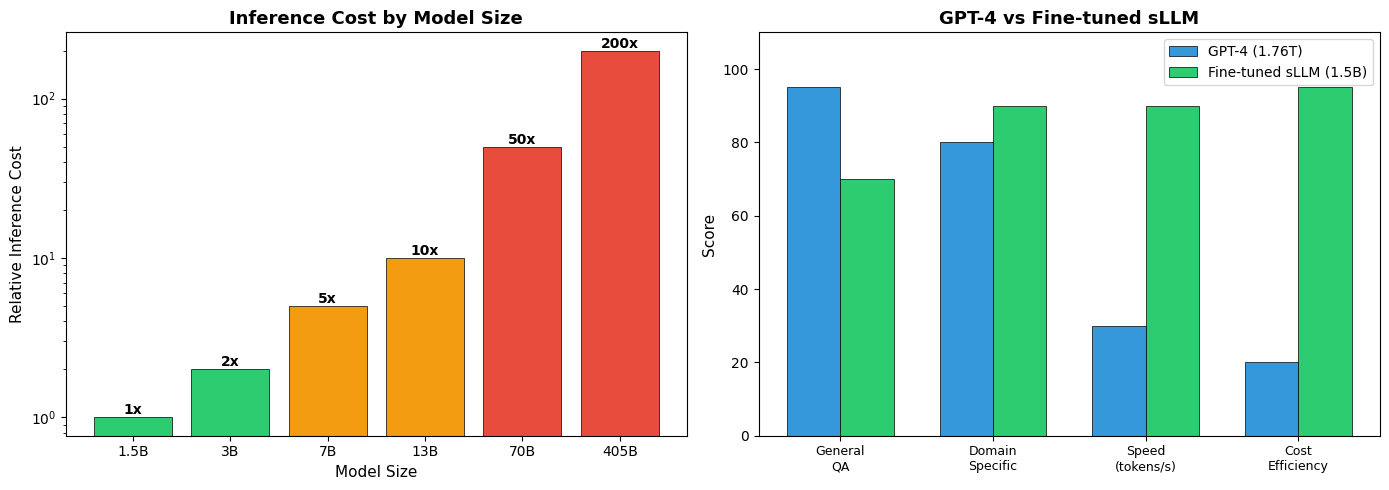


✅ 파인튜닝된 sLLM은 도메인 특화 작업에서 대형 모델을 능가할 수 있습니다!
💡 비용 효율과 속도에서는 압도적 우위를 가집니다.


In [4]:
# sLLM vs 대형 모델 비교 시각화
print("=" * 60)
print("📊 sLLM vs 대형 모델: 비용-성능 트레이드오프")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델 크기별 추론 비용 비교
ax1 = axes[0]
model_sizes = ['1.5B', '3B', '7B', '13B', '70B', '405B']
costs_relative = [1, 2, 5, 10, 50, 200]  # 상대적 비용
colors_bar = ['#2ecc71', '#2ecc71', '#f39c12', '#f39c12', '#e74c3c', '#e74c3c']

bars = ax1.bar(model_sizes, costs_relative, color=colors_bar, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Model Size', fontsize=11)
ax1.set_ylabel('Relative Inference Cost', fontsize=11)
ax1.set_title('Inference Cost by Model Size', fontsize=13, fontweight='bold')
ax1.set_yscale('log')

for bar, cost in zip(bars, costs_relative):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{cost}x', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 오른쪽: 도메인 특화 성능 비교
ax2 = axes[1]
categories = ['General\nQA', 'Domain\nSpecific', 'Speed\n(tokens/s)', 'Cost\nEfficiency']
gpt4_scores = [95, 80, 30, 20]
finetuned_sllm = [70, 90, 90, 95]

x = range(len(categories))
width = 0.35
ax2.bar([i - width/2 for i in x], gpt4_scores, width, label='GPT-4 (1.76T)', color='#3498db', edgecolor='black', linewidth=0.5)
ax2.bar([i + width/2 for i in x], finetuned_sllm, width, label='Fine-tuned sLLM (1.5B)', color='#2ecc71', edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('GPT-4 vs Fine-tuned sLLM', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=9)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print("\n✅ 파인튜닝된 sLLM은 도메인 특화 작업에서 대형 모델을 능가할 수 있습니다!")
print("💡 비용 효율과 속도에서는 압도적 우위를 가집니다.")

---

## 3️⃣ LLM 활용 4가지 방법 비교

LLM을 실제 업무에 활용하는 방법은 크게 4가지로 나눌 수 있습니다.

### 개요

```
┌────────────────────────────────────────────────────────────────┐
│                    LLM 활용 4가지 방법                          │
├────────────────┬───────────────┬──────────────┬───────────────┤
│ 프롬프트        │ RAG           │ Agent        │ 파인튜닝       │
│ 엔지니어링      │               │              │               │
├────────────────┼───────────────┼──────────────┼───────────────┤
│ 지시문 최적화   │ 외부 지식 검색  │ 도구 활용     │ 모델 자체 학습  │
│ 가장 간단      │ 지식 보강      │ 자율 행동     │ 가장 심화      │
│ 모델 변경 없음  │ 모델 변경 없음  │ 모델 변경 없음 │ 모델 가중치 수정│
└────────────────┴───────────────┴──────────────┴───────────────┘
```

---

In [5]:
# 4가지 방법 상세 비교
print("=" * 80)
print("📋 LLM 활용 4가지 방법 상세 비교")
print("=" * 80)

methods = [
    {
        "name": "1. 프롬프트 엔지니어링",
        "description": "모델에 주는 지시문(프롬프트)을 최적화",
        "difficulty": "⭐ (쉬움)",
        "cost": "💰 (낮음)",
        "gpu": "불필요",
        "data": "불필요",
        "time": "분 단위",
        "pros": "즉시 적용, 비용 낮음",
        "cons": "성능 한계, 복잡한 작업 어려움",
    },
    {
        "name": "2. RAG (검색 증강 생성)",
        "description": "외부 문서를 검색하여 LLM에 제공",
        "difficulty": "⭐⭐ (보통)",
        "cost": "💰💰 (중간)",
        "gpu": "임베딩용 소규모",
        "data": "문서/지식 베이스",
        "time": "일~주 단위",
        "pros": "최신 정보 반영, 환각 감소",
        "cons": "검색 품질 의존, 파이프라인 복잡",
    },
    {
        "name": "3. Agent (에이전트)",
        "description": "LLM이 도구를 사용하여 자율적 행동",
        "difficulty": "⭐⭐⭐ (높음)",
        "cost": "💰💰💰 (높음)",
        "gpu": "불필요 (API 사용)",
        "data": "도구 정의",
        "time": "주 단위",
        "pros": "복잡한 작업 자동화, 외부 시스템 연동",
        "cons": "비용 높음, 예측 어려움, 디버깅 복잡",
    },
    {
        "name": "4. 파인튜닝 (Fine-tuning)",
        "description": "모델 가중치를 직접 학습하여 수정",
        "difficulty": "⭐⭐⭐⭐ (매우 높음)",
        "cost": "💰💰 (GPU 비용)",
        "gpu": "필수 (8GB+)",
        "data": "학습 데이터셋 필요",
        "time": "일~주 단위",
        "pros": "도메인 특화, 성능 극대화, 추론 비용 절감",
        "cons": "데이터/GPU 필요, 학습 시간, 전문 지식",
    },
]

for m in methods:
    print(f"\n{'─' * 80}")
    print(f"📌 {m['name']}")
    print(f"   설명: {m['description']}")
    print(f"   난이도: {m['difficulty']}  |  비용: {m['cost']}")
    print(f"   GPU: {m['gpu']}  |  데이터: {m['data']}  |  소요시간: {m['time']}")
    print(f"   ✅ 장점: {m['pros']}")
    print(f"   ⚠️ 단점: {m['cons']}")

print(f"\n{'═' * 80}")
print("💡 이 과정에서는 4가지 방법을 모두 학습하고, 특히 파인튜닝에 집중합니다!")

📋 LLM 활용 4가지 방법 상세 비교

────────────────────────────────────────────────────────────────────────────────
📌 1. 프롬프트 엔지니어링
   설명: 모델에 주는 지시문(프롬프트)을 최적화
   난이도: ⭐ (쉬움)  |  비용: 💰 (낮음)
   GPU: 불필요  |  데이터: 불필요  |  소요시간: 분 단위
   ✅ 장점: 즉시 적용, 비용 낮음
   ⚠️ 단점: 성능 한계, 복잡한 작업 어려움

────────────────────────────────────────────────────────────────────────────────
📌 2. RAG (검색 증강 생성)
   설명: 외부 문서를 검색하여 LLM에 제공
   난이도: ⭐⭐ (보통)  |  비용: 💰💰 (중간)
   GPU: 임베딩용 소규모  |  데이터: 문서/지식 베이스  |  소요시간: 일~주 단위
   ✅ 장점: 최신 정보 반영, 환각 감소
   ⚠️ 단점: 검색 품질 의존, 파이프라인 복잡

────────────────────────────────────────────────────────────────────────────────
📌 3. Agent (에이전트)
   설명: LLM이 도구를 사용하여 자율적 행동
   난이도: ⭐⭐⭐ (높음)  |  비용: 💰💰💰 (높음)
   GPU: 불필요 (API 사용)  |  데이터: 도구 정의  |  소요시간: 주 단위
   ✅ 장점: 복잡한 작업 자동화, 외부 시스템 연동
   ⚠️ 단점: 비용 높음, 예측 어려움, 디버깅 복잡

────────────────────────────────────────────────────────────────────────────────
📌 4. 파인튜닝 (Fine-tuning)
   설명: 모델 가중치를 직접 학습하여 수정
   난이도: ⭐⭐⭐⭐ (매우 높음)  |  비용: 💰💰 (GPU 비용)
   GPU: 필수 (8G

---

## 4️⃣ 각 방법의 적합한 사용 사례

### 의사결정 플로우차트

```
LLM 활용이 필요한 작업
        │
        ▼
  ┌─ 기존 모델로 충분한가? ──── Yes ──▶ 프롬프트 엔지니어링
  │       │
  │      No
  │       ▼
  ├─ 최신/특정 지식이 필요한가? ── Yes ──▶ RAG
  │       │
  │      No
  │       ▼
  ├─ 외부 도구/시스템 연동? ──── Yes ──▶ Agent
  │       │
  │      No
  │       ▼
  └─ 도메인 특화/스타일 변경? ── Yes ──▶ 파인튜닝
```

---

In [6]:
# 각 방법의 구체적 사용 사례
print("=" * 80)
print("📋 각 방법의 구체적 사용 사례")
print("=" * 80)

use_cases = {
    "프롬프트 엔지니어링": [
        "이메일 작성/요약",
        "번역",
        "간단한 질의응답",
        "텍스트 분류 (감성 분석 등)",
        "코드 설명/리뷰",
        "Few-shot 학습 (예시 기반)",
    ],
    "RAG": [
        "사내 문서 검색 & 답변",
        "법률/의료 문서 기반 QA",
        "최신 뉴스 기반 요약",
        "제품 매뉴얼 기반 고객 지원",
        "학술 논문 검색 & 요약",
        "FAQ 자동 응답 시스템",
    ],
    "Agent": [
        "데이터 분석 자동화 (SQL + 시각화)",
        "웹 검색 → 정보 수집 → 보고서 작성",
        "이메일 자동 분류 & 응답",
        "코드 작성 → 테스트 → 디버깅",
        "예약/주문 처리 챗봇",
        "멀티스텝 업무 자동화",
    ],
    "파인튜닝": [
        "도메인 특화 챗봇 (금융, 의료, 법률)",
        "특정 스타일/톤의 글쓰기",
        "사내 용어/프로세스 이해",
        "특수 포맷 출력 (JSON, 코드 등)",
        "Tool Calling 최적화",
        "추론 비용 절감 (대형 → 소형 모델)",
    ],
}

for method, cases in use_cases.items():
    print(f"\n📌 {method}")
    for i, case in enumerate(cases, 1):
        print(f"   {i}. {case}")

print(f"\n{'═' * 80}")
print("💡 실제로는 이 방법들을 조합하여 사용하는 경우가 많습니다!")
print("   예: 파인튜닝된 모델 + RAG = 도메인 특화 + 최신 지식")

📋 각 방법의 구체적 사용 사례

📌 프롬프트 엔지니어링
   1. 이메일 작성/요약
   2. 번역
   3. 간단한 질의응답
   4. 텍스트 분류 (감성 분석 등)
   5. 코드 설명/리뷰
   6. Few-shot 학습 (예시 기반)

📌 RAG
   1. 사내 문서 검색 & 답변
   2. 법률/의료 문서 기반 QA
   3. 최신 뉴스 기반 요약
   4. 제품 매뉴얼 기반 고객 지원
   5. 학술 논문 검색 & 요약
   6. FAQ 자동 응답 시스템

📌 Agent
   1. 데이터 분석 자동화 (SQL + 시각화)
   2. 웹 검색 → 정보 수집 → 보고서 작성
   3. 이메일 자동 분류 & 응답
   4. 코드 작성 → 테스트 → 디버깅
   5. 예약/주문 처리 챗봇
   6. 멀티스텝 업무 자동화

📌 파인튜닝
   1. 도메인 특화 챗봇 (금융, 의료, 법률)
   2. 특정 스타일/톤의 글쓰기
   3. 사내 용어/프로세스 이해
   4. 특수 포맷 출력 (JSON, 코드 등)
   5. Tool Calling 최적화
   6. 추론 비용 절감 (대형 → 소형 모델)

════════════════════════════════════════════════════════════════════════════════
💡 실제로는 이 방법들을 조합하여 사용하는 경우가 많습니다!
   예: 파인튜닝된 모델 + RAG = 도메인 특화 + 최신 지식


In [7]:
# 조합 활용 패턴
print("=" * 80)
print("🔄 실무에서 자주 사용하는 조합 패턴")
print("=" * 80)

patterns = [
    {
        "pattern": "프롬프트 엔지니어링 + RAG",
        "description": "검색된 문서를 잘 정리된 프롬프트에 삽입",
        "example": "사내 위키 기반 QA 시스템",
        "difficulty": "중",
    },
    {
        "pattern": "파인튜닝 + RAG",
        "description": "도메인 이해력을 높인 모델 + 외부 지식 검색",
        "example": "의료 상담 AI (의학 파인튜닝 + 최신 논문 검색)",
        "difficulty": "상",
    },
    {
        "pattern": "파인튜닝 + Agent",
        "description": "Tool Calling에 최적화된 모델 + 외부 도구 연동",
        "example": "자동 데이터 분석 AI (DB 쿼리 + 시각화 도구)",
        "difficulty": "상",
    },
    {
        "pattern": "프롬프트 + Agent + RAG",
        "description": "에이전트가 RAG를 도구로 활용",
        "example": "연구 보조 AI (논문 검색 → 요약 → 비교 분석)",
        "difficulty": "상",
    },
]

for i, p in enumerate(patterns, 1):
    print(f"\n{i}️⃣ {p['pattern']} (난이도: {p['difficulty']})")
    print(f"   📝 설명: {p['description']}")
    print(f"   💼 예시: {p['example']}")

print(f"\n{'═' * 80}")
print("✅ 이 과정에서 이 조합들을 모두 실습해볼 예정입니다!")

🔄 실무에서 자주 사용하는 조합 패턴

1️⃣ 프롬프트 엔지니어링 + RAG (난이도: 중)
   📝 설명: 검색된 문서를 잘 정리된 프롬프트에 삽입
   💼 예시: 사내 위키 기반 QA 시스템

2️⃣ 파인튜닝 + RAG (난이도: 상)
   📝 설명: 도메인 이해력을 높인 모델 + 외부 지식 검색
   💼 예시: 의료 상담 AI (의학 파인튜닝 + 최신 논문 검색)

3️⃣ 파인튜닝 + Agent (난이도: 상)
   📝 설명: Tool Calling에 최적화된 모델 + 외부 도구 연동
   💼 예시: 자동 데이터 분석 AI (DB 쿼리 + 시각화 도구)

4️⃣ 프롬프트 + Agent + RAG (난이도: 상)
   📝 설명: 에이전트가 RAG를 도구로 활용
   💼 예시: 연구 보조 AI (논문 검색 → 요약 → 비교 분석)

════════════════════════════════════════════════════════════════════════════════
✅ 이 과정에서 이 조합들을 모두 실습해볼 예정입니다!


---

## 5️⃣ 시각화: 모델 크기 vs 성능 트렌드

### Scaling Law (스케일링 법칙)

모델 성능은 3가지 요인에 의해 결정됩니다:

1. **모델 크기** (파라미터 수)
2. **데이터 양** (학습 토큰 수)
3. **연산량** (컴퓨트)

하지만 최근에는 **데이터 품질**과 **학습 기법**이 더 중요하다는 인식이 확산되고 있습니다.

---

📈 모델 크기 vs 성능 (벤치마크 기준) 시각화


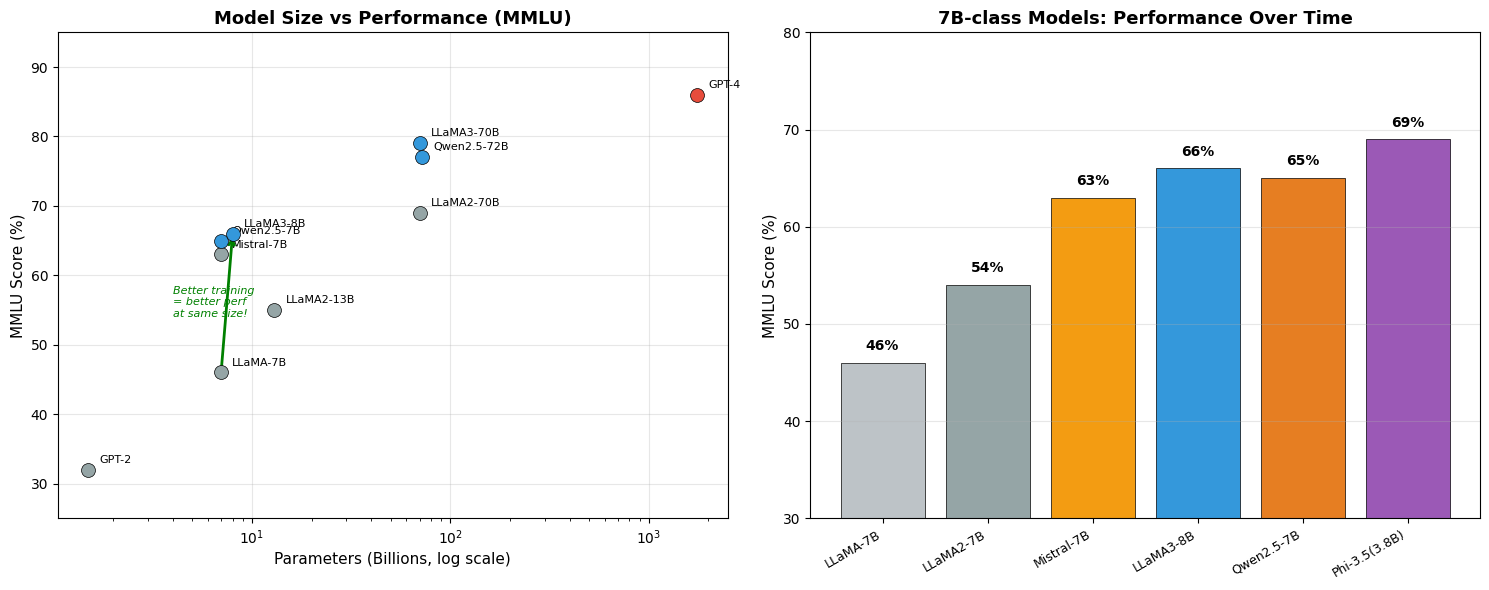


✅ 같은 크기(7B)의 모델이라도 학습 기법 발전으로 성능이 크게 향상됩니다!
💡 핵심: 큰 모델 = 좋은 모델이 아니라, 좋은 데이터 + 좋은 학습 = 좋은 모델!


In [8]:
# 모델 크기 vs 성능 트렌드 시각화
print("=" * 60)
print("📈 모델 크기 vs 성능 (벤치마크 기준) 시각화")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: 모델 크기 vs MMLU 성능 (가상 데이터, 트렌드 표현용)
ax1 = axes[0]

# 모델 데이터 (파라미터 수 B, MMLU 점수 근사)
model_data = [
    ("GPT-2", 1.5, 32),
    ("LLaMA-7B", 7, 46),
    ("Mistral-7B", 7, 63),
    ("LLaMA2-13B", 13, 55),
    ("Qwen2.5-7B", 7, 65),
    ("LLaMA2-70B", 70, 69),
    ("Qwen2.5-72B", 72, 77),
    ("LLaMA3-8B", 8, 66),
    ("LLaMA3-70B", 70, 79),
    ("GPT-4", 1760, 86),
]

for name, params, score in model_data:
    color = '#e74c3c' if 'GPT-4' in name else '#3498db' if 'LLaMA3' in name or 'Qwen2.5' in name else '#95a5a6'
    ax1.scatter(params, score, s=100, c=color, edgecolors='black', linewidth=0.5, zorder=5)
    ax1.annotate(name, (params, score), textcoords="offset points", 
                xytext=(8, 5), fontsize=8)

ax1.set_xscale('log')
ax1.set_xlabel('Parameters (Billions, log scale)', fontsize=11)
ax1.set_ylabel('MMLU Score (%)', fontsize=11)
ax1.set_title('Model Size vs Performance (MMLU)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(25, 95)

# 트렌드 화살표 - 2023 vs 2024 모델
ax1.annotate('', xy=(8, 66), xytext=(7, 46),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax1.text(4, 54, 'Better training\n= better perf\nat same size!', 
        fontsize=8, color='green', style='italic')

# 오른쪽: 연도별 동일 크기(7B) 모델 성능 향상
ax2 = axes[1]

years = [2023, 2023.3, 2023.6, 2024, 2024.3, 2024.6]
model_names_7b = ['LLaMA-7B', 'LLaMA2-7B', 'Mistral-7B', 'LLaMA3-8B', 'Qwen2.5-7B', 'Phi-3.5(3.8B)']
scores_7b = [46, 54, 63, 66, 65, 69]

bars = ax2.bar(range(len(model_names_7b)), scores_7b, 
              color=['#bdc3c7', '#95a5a6', '#f39c12', '#3498db', '#e67e22', '#9b59b6'],
              edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(model_names_7b)))
ax2.set_xticklabels(model_names_7b, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('MMLU Score (%)', fontsize=11)
ax2.set_title('7B-class Models: Performance Over Time', fontsize=13, fontweight='bold')
ax2.set_ylim(30, 80)
ax2.grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars, scores_7b):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{score}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ 같은 크기(7B)의 모델이라도 학습 기법 발전으로 성능이 크게 향상됩니다!")
print("💡 핵심: 큰 모델 = 좋은 모델이 아니라, 좋은 데이터 + 좋은 학습 = 좋은 모델!")

🖥️ RTX 4060 (8GB VRAM)으로 가능한 작업 범위


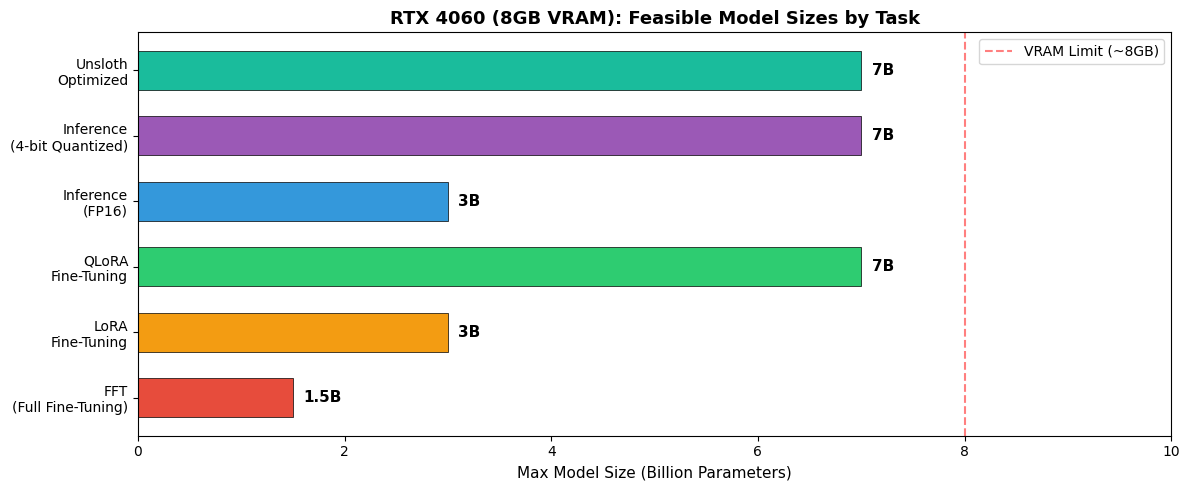


✅ RTX 4060에서도 QLoRA를 활용하면 7B 모델까지 파인튜닝 가능!
💡 우리 실습에서는 주로 Qwen2.5-1.5B-Instruct를 사용합니다.


In [9]:
# RTX 4060으로 실행 가능한 모델 범위 시각화
print("=" * 60)
print("🖥️ RTX 4060 (8GB VRAM)으로 가능한 작업 범위")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 5))

# 작업 유형과 가능한 모델 크기
tasks = [
    ('FFT\n(Full Fine-Tuning)', 1.5, '#e74c3c'),
    ('LoRA\nFine-Tuning', 3, '#f39c12'),
    ('QLoRA\nFine-Tuning', 7, '#2ecc71'),
    ('Inference\n(FP16)', 3, '#3498db'),
    ('Inference\n(4-bit Quantized)', 7, '#9b59b6'),
    ('Unsloth\nOptimized', 7, '#1abc9c'),
]

y_pos = range(len(tasks))
sizes = [t[1] for t in tasks]
colors_h = [t[2] for t in tasks]
labels = [t[0] for t in tasks]

bars = ax.barh(y_pos, sizes, color=colors_h, edgecolor='black', linewidth=0.5, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Max Model Size (Billion Parameters)', fontsize=11)
ax.set_title('RTX 4060 (8GB VRAM): Feasible Model Sizes by Task', fontsize=13, fontweight='bold')
ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='VRAM Limit (~8GB)')
ax.legend(fontsize=10)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
           f'{size}B', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

print("\n✅ RTX 4060에서도 QLoRA를 활용하면 7B 모델까지 파인튜닝 가능!")
print("💡 우리 실습에서는 주로 Qwen2.5-1.5B-Instruct를 사용합니다.")

---

## 📝 정리 및 핵심 요약

### 이번 세션에서 배운 내용

| 주제 | 핵심 내용 |
|------|----------|
| LLM 발전 | 2017 Transformer → 2025 멀티모달/추론 모델 |
| 주요 모델 | GPT-4, Claude, LLaMA, Qwen, Mistral 등 |
| sLLM | 7B 이하 경량 모델, 파인튜닝으로 도메인 특화 가능 |
| 활용 방법 | 프롬프트 < RAG < Agent < 파인튜닝 (복잡도 순) |
| 의사결정 | 상황에 맞는 방법 선택이 중요 |

### 핵심 메시지

- 🔑 **"큰 모델 = 좋은 모델"이 아닙니다**
  - 좋은 데이터 + 좋은 학습 기법이 더 중요
  
- 🔑 **파인튜닝된 sLLM은 특정 도메인에서 대형 모델을 능가할 수 있습니다**
  - 비용은 1/100, 속도는 10배 이상 빠름
  
- 🔑 **4가지 방법을 적절히 조합하는 것이 실무의 핵심**
  - 프롬프트 엔지니어링으로 시작 → 필요에 따라 RAG, Agent, 파인튜닝 추가

### 다음 세션 예고

- 🔜 OpenAI API 실습: Chat Completions, 스트리밍, 멀티턴 대화
- 🔜 실제 API를 호출하여 LLM과 상호작용해보겠습니다!

---

### 💡 실습 과제

1. 최근 출시된 LLM 모델 하나를 선택하여 특징을 정리해보세요.
2. 자신의 업무/관심 분야에서 LLM을 활용한다면, 4가지 방법 중 어떤 것이 적합할지 판단해보세요.
3. (선택) HuggingFace Open LLM Leaderboard를 방문하여 최신 벤치마크 결과를 확인해보세요.

---